# Customer Analysis
Source: customers_clean.parquet

Covers: age distribution, gender split, geography

### Imports & setup

In [1]:
import pandas as pd
from src.analysis import customers
from src.viz import base

### Load Data

In [2]:
df = pd.read_parquet("../data/processed/customers_clean.parquet")
print(df.shape)
df.head()

(15266, 12)


,CustomerKey,Gender,Name,City,State Code,State,Zip Code,Country,Continent,Birthday,Age,Age Group
0,301,Female,Lilly Harding,WANDEARAH EAST,SA,South Australia,5523,Australia,Australia,1939-07-03,86,65+
1,325,Female,Madison Hull,MOUNT BUDD,WA,Western Australia,6522,Australia,Australia,1979-09-27,46,35-49
2,554,Female,Claire Ferres,WINJALLOK,VIC,Victoria,3380,Australia,Australia,1947-05-26,78,65+
3,786,Male,Jai Poltpalingada,MIDDLE RIVER,SA,South Australia,5223,Australia,Australia,1957-09-17,68,65+
4,1042,Male,Aidan Pankhurst,TAWONGA SOUTH,VIC,Victoria,3698,Australia,Australia,1965-11-19,60,50-64


## Age Distribution

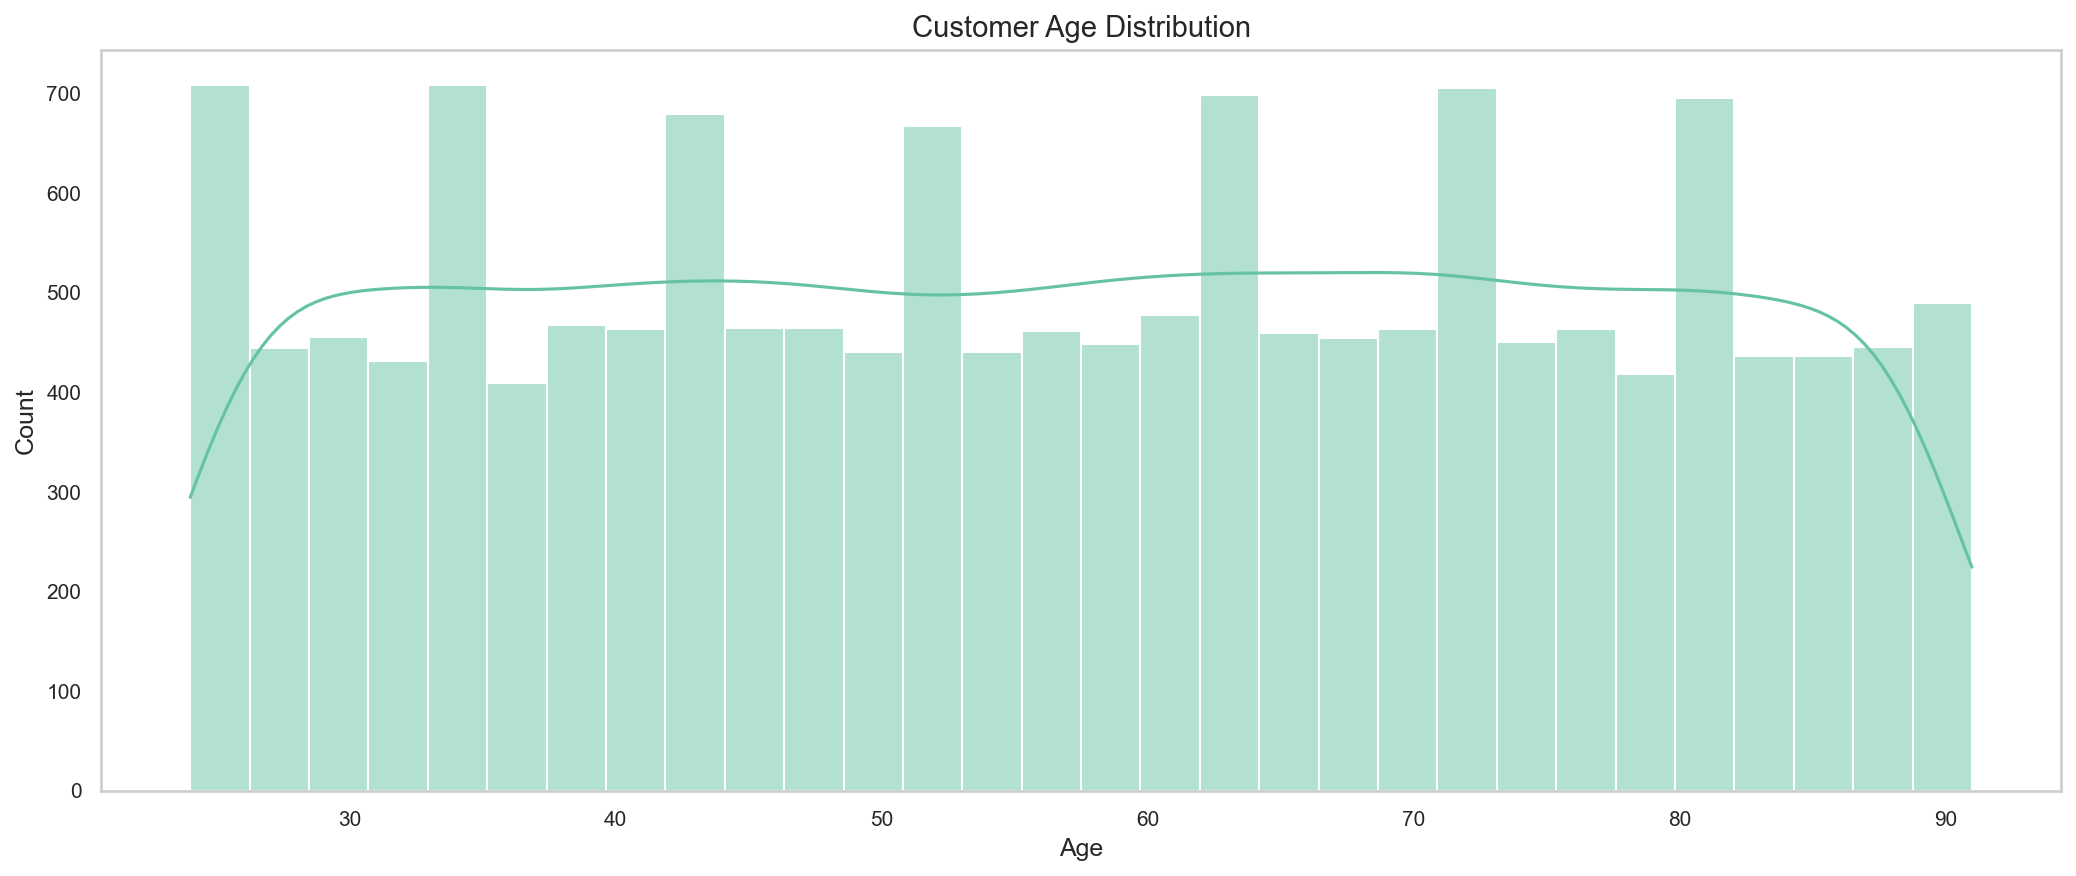

In [3]:
age_data = customers.age_distribution(df)
fig, ax = base.histogram(
    age_data,
    title="Customer Age Distribution",
    xlabel="Age",
    ylabel="Count",
    filename="customers_age_distribution.png"
)

display(fig)


## Age Group Split

,Age Group,count,pct
0,65+,5925,38.81
1,50-64,3410,22.34
2,35-49,3404,22.30
3,25-34,2306,15.11
4,<25,221,1.45


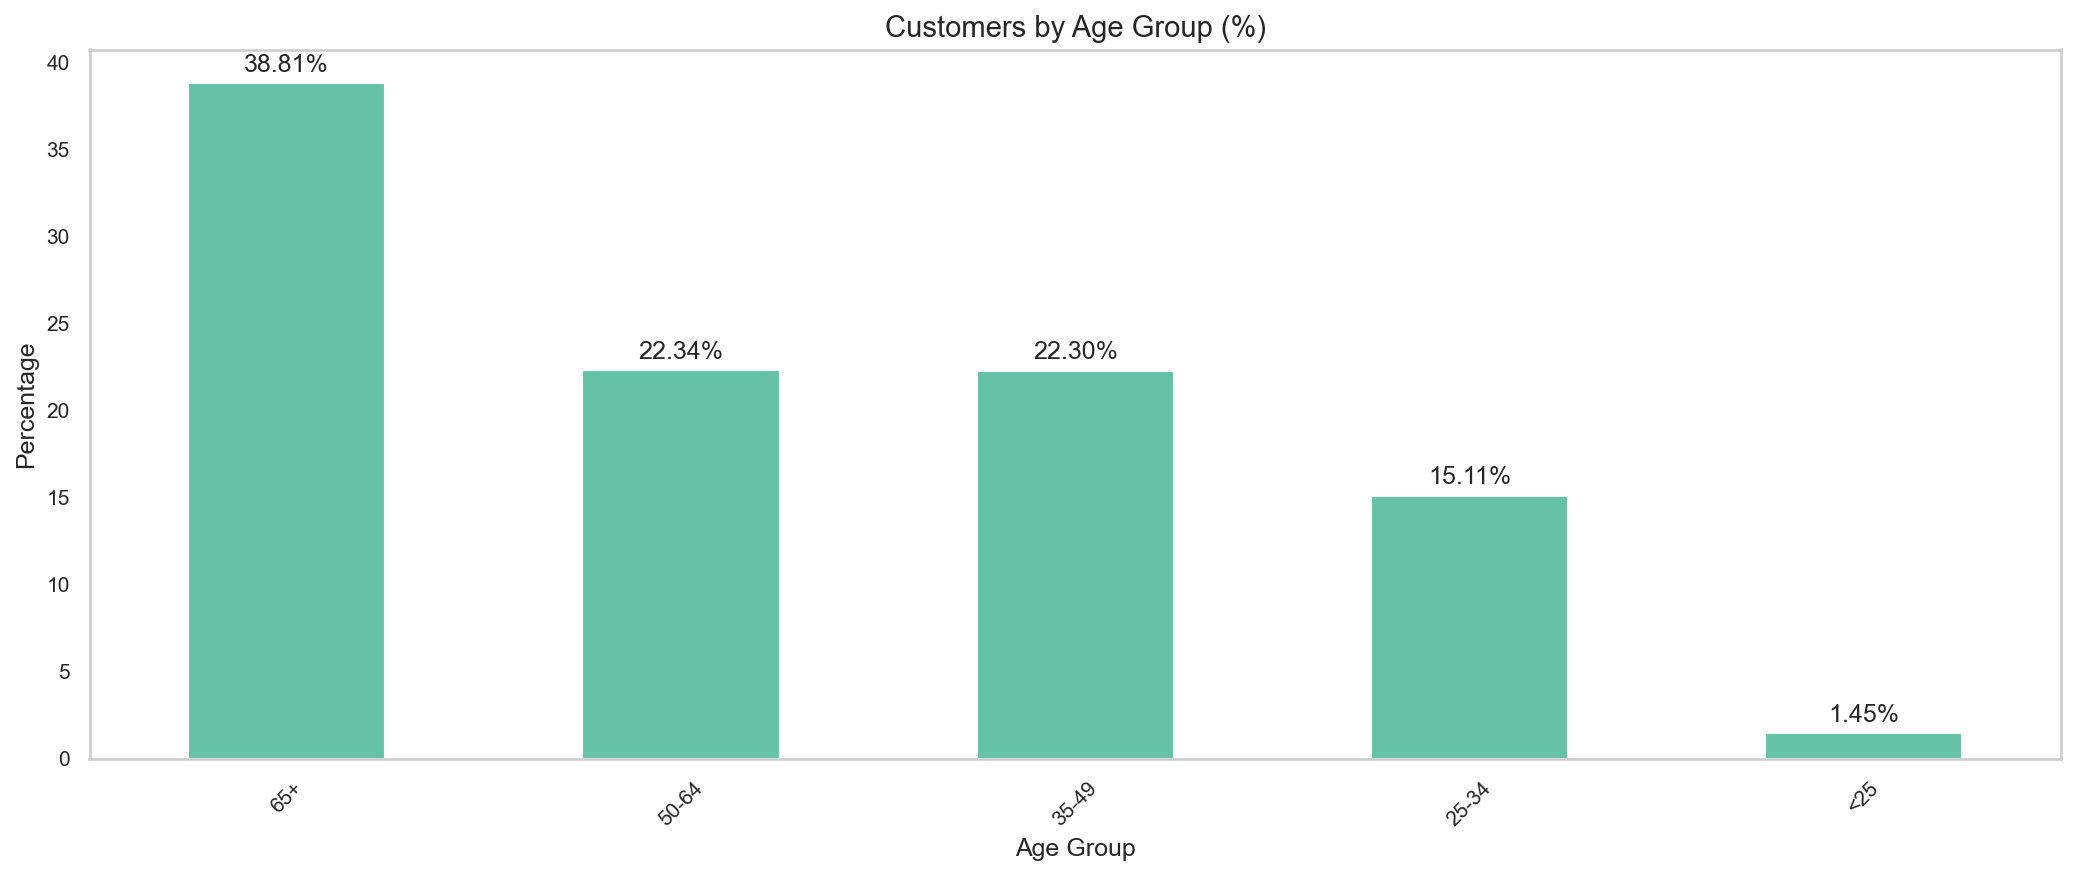

In [4]:
age_groups = customers.age_group_split(df)
display(age_groups)
fig, ax = base.bar(
    age_groups.set_index("Age Group")["pct"],
    title="Customers by Age Group (%)",
    xlabel="Age Group",
    ylabel="Percentage",
    filename="customers_age_group_split.png",
    is_pct=True
)

display(fig)

## Gender Split

Gender
Male      50.75
Female    49.25
Name: count, dtype: float64

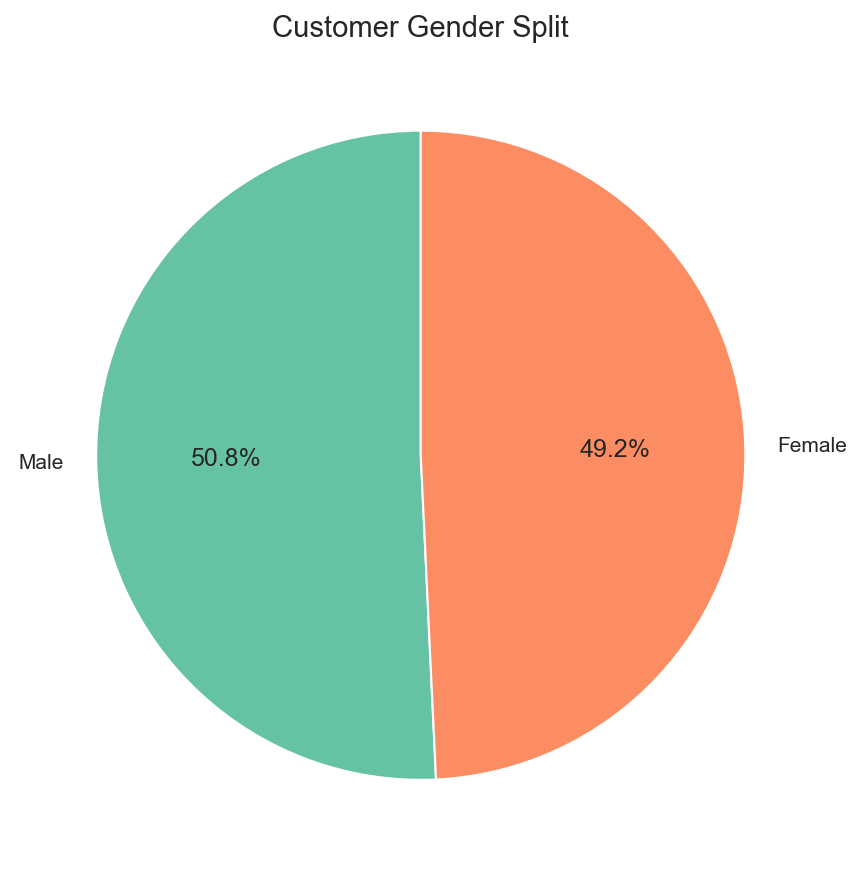

In [5]:
gender = customers.gender_split(df)
display(gender)
fig, ax = base.pie(
    gender,
    title="Customer Gender Split",
    filename="customers_gender_split.png"
)


display(fig)

## Customers by Country (Top 10)

Country
United States     6828
United Kingdom    1944
Canada            1553
Germany           1473
Australia         1420
Netherlands        733
France             670
Italy              645
dtype: int64

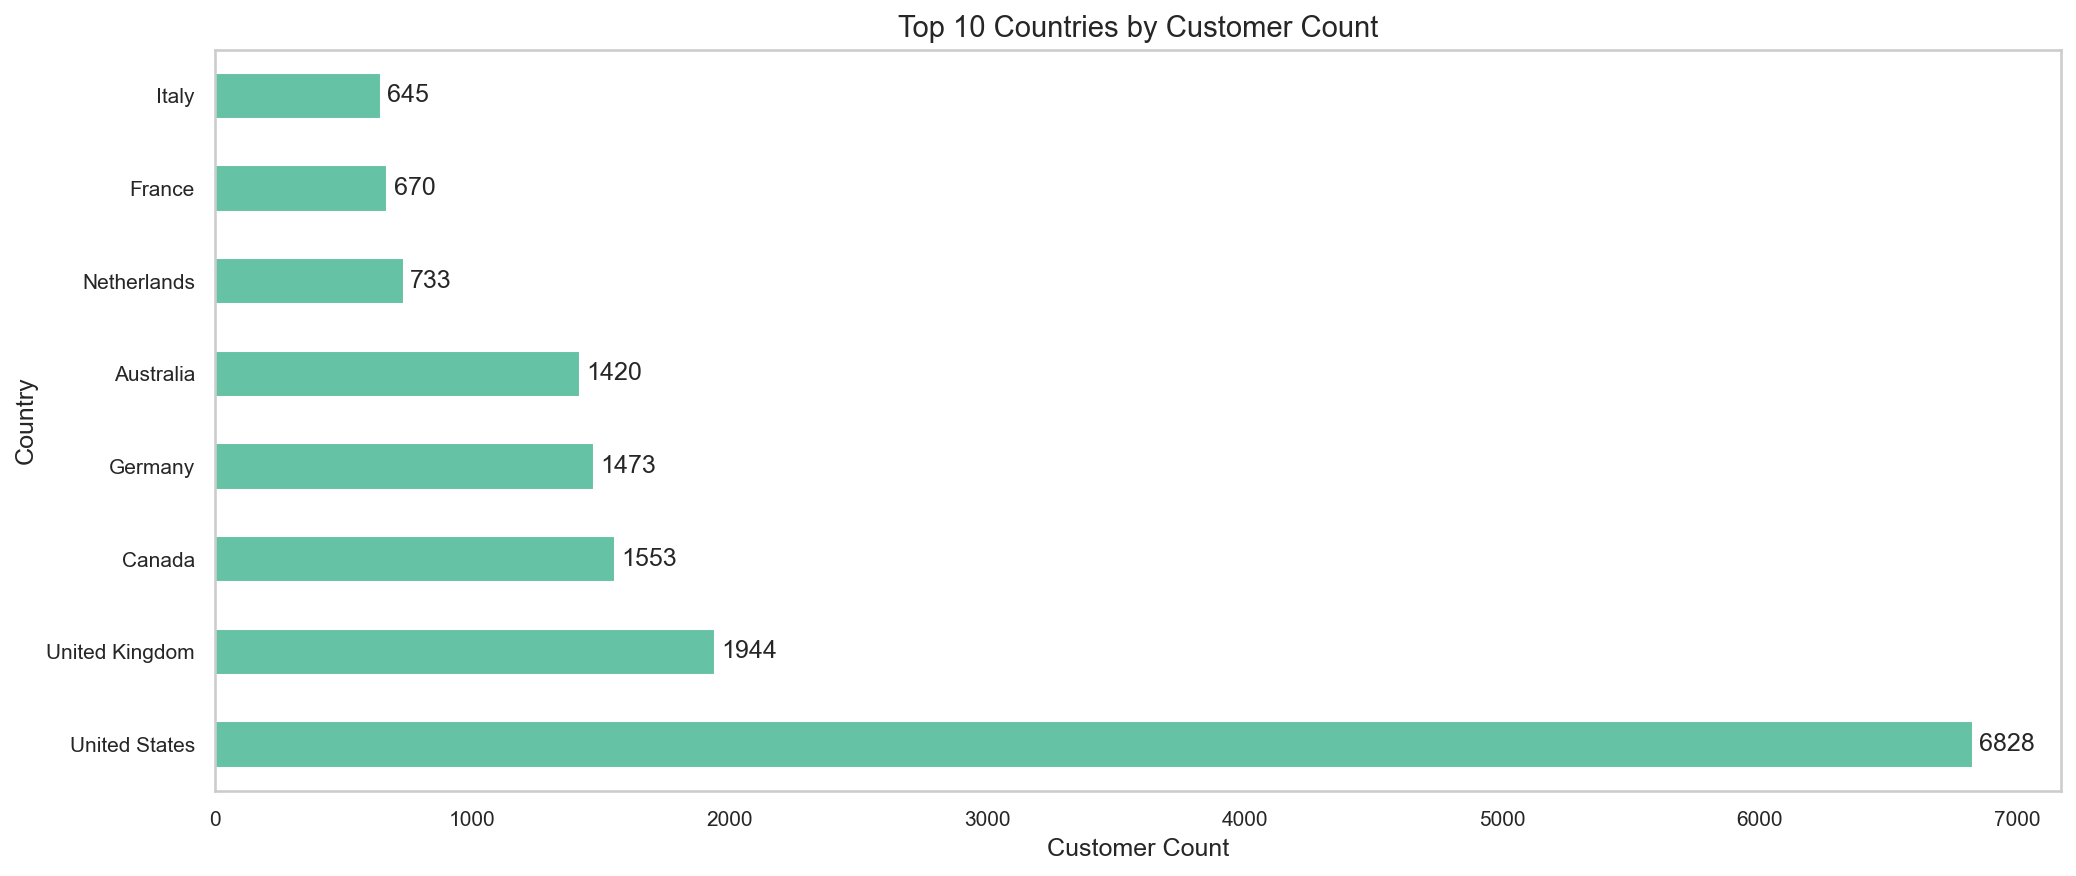

In [6]:
by_country = customers.customers_by_country(df, n=10)
display(by_country)
fig, ax = base.horizontal_bar(
    by_country,
    title="Top 10 Countries by Customer Count",
    xlabel="Customer Count",
    ylabel="Country",
    filename="customers_by_country.png"
)

display(fig)

## Customers by Continent

Continent
North America    54.9
Europe           35.8
Australia         9.3
Name: count, dtype: float64

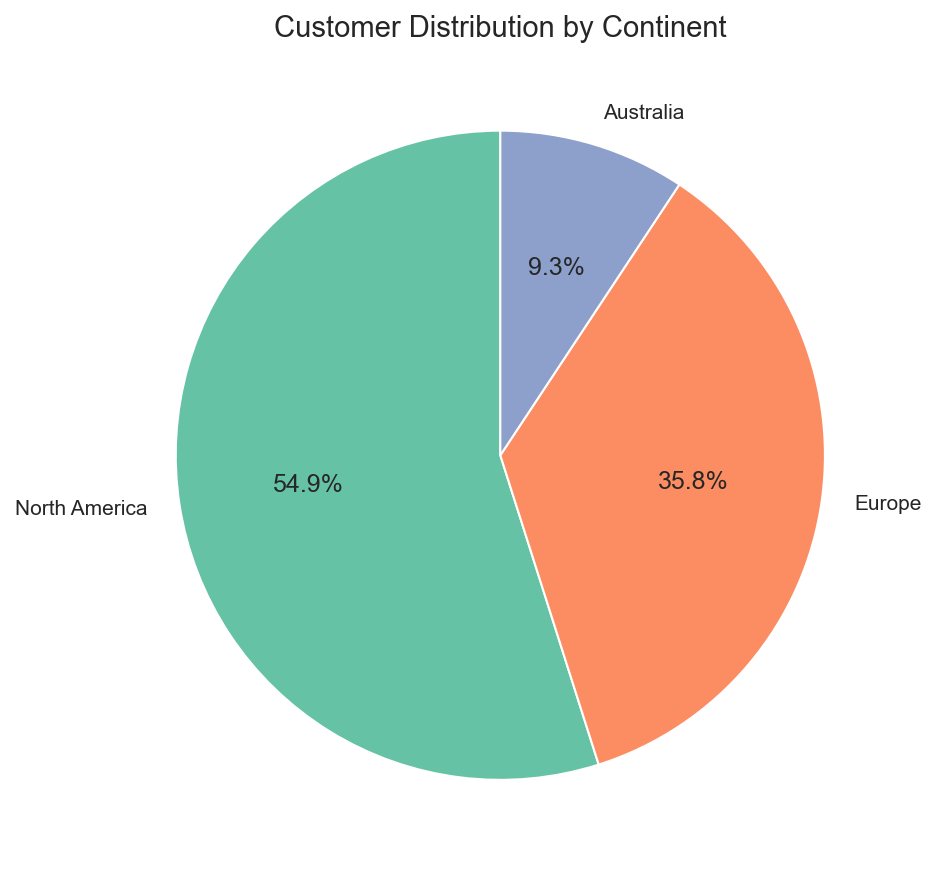

In [7]:
by_continent = customers.customers_by_continent(df)
display(by_continent)
fig, ax = base.pie(
    by_continent,
    title="Customer Distribution by Continent",
    filename="customers_by_continent.png"
)

display(fig)

## Gender Split by Country (Top 10)

Gender,Female,Male
Country,,
Australia,721,699
Canada,755,798
France,351,319
Germany,734,739
Italy,319,326
Netherlands,345,388
United Kingdom,938,1006
United States,3355,3473


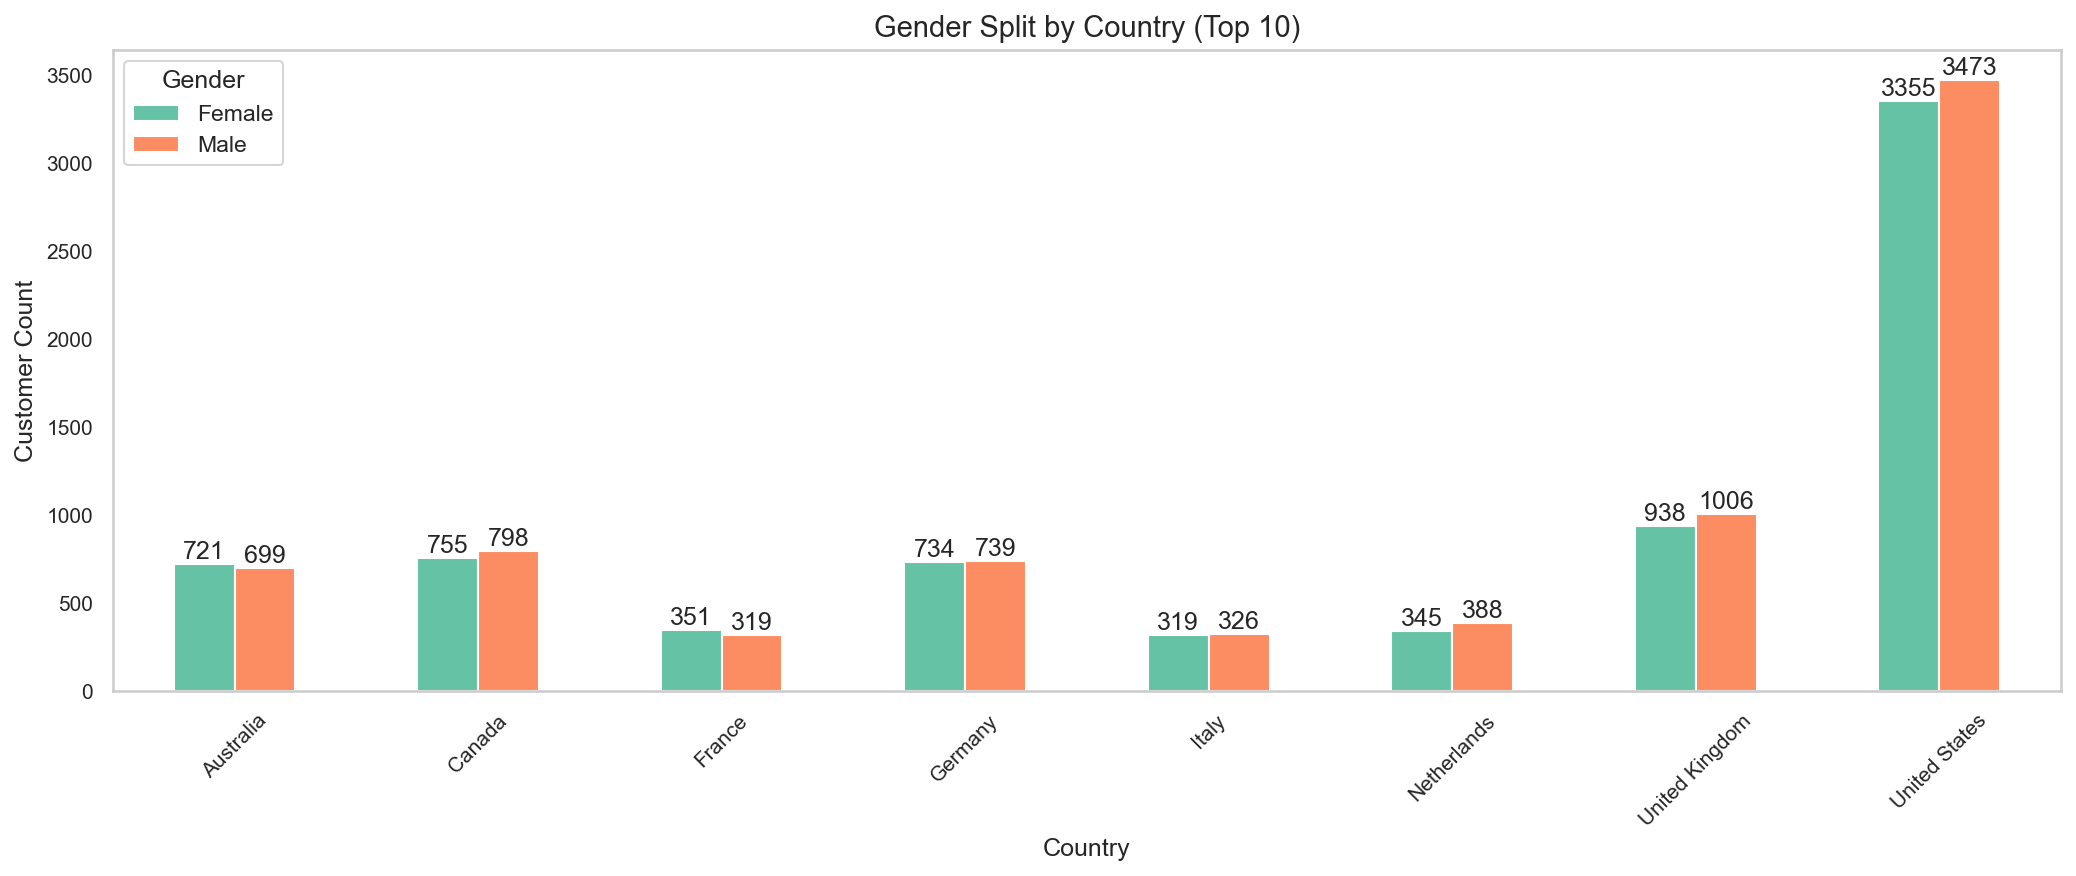

In [8]:
gender_country = customers.gender_by_country(df, n=10)
display(gender_country)
fig, ax = base.new_fig()

gender_country.plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("Gender Split by Country (Top 10)")
ax.set_xlabel("Country")
ax.set_ylabel("Customer Count")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()

for i in ax.containers:
    ax.bar_label(i, fmt="%.0f")

base.save(fig, "customers_gender_by_country.png")


display(fig)

## Age Summary Statistics

In [9]:
stats = customers.age_stats(df)
display(stats)

count    15266.00
mean        57.01
std         19.33
min         24.00
25%         40.00
50%         57.00
75%         74.00
max         91.00
Name: Age, dtype: float64

## Customer Analysis — Findings

### Age Distribution
- Customer ages span evenly from 25 to 90 with no significant concentration at any single age.
- The KDE curve confirms a near-uniform distribution across the full range, with a slight natural decline after age 85.
- No meaningful younger customer base exists — customers under 25 represent just 1% of the total.

### Age Group Split
- 65+ is the largest segment at 39% — nearly 4 in 10 customers are senior.
- 50-64 and 35-49 are equal at 22% each, forming the mid-tier base.
- 25-34 accounts for 15%, and under-25 is negligible at 1%.
- The business skews heavily toward older demographics. Any targeting strategy must account for this.

### Gender Split
- Gender is near perfectly balanced — Male 50.8%, Female 49.2%.
- No gender-specific marketing strategy is warranted based on volume alone.
- However, gender split by country shows minor variations worth monitoring at a regional level.

### Geography — Continent
- North America dominates at 54.9% of the customer base.
- Europe follows at 35.8%.
- Australia accounts for 9.3% — present but a distant third.
- No customers from Asia, Africa, or South America — a significant gap in global reach.

### Geography — Country
- United States alone accounts for 6,828 customers — more than the next 7 countries combined.
- United Kingdom (1,944) and Canada (1,553) are the only other markets with meaningful scale.
- Germany (1,473) and Australia (1,420) are comparable in size.
- Italy, France, and Netherlands are the smallest markets in the top 10, all under 750.

### Gender by Country
- Gender split is consistent and near-equal across all top 10 countries.
- No country shows a skew large enough to indicate a structural difference in customer acquisition.